# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** [cdcc192d6y1241@student.devacademy.id]
- **Email:** [Input Email]
- **ID Dicoding:** [cdcc192d6y1241]

## Menentukan Pertanyaan Bisnis

- **“Bagaimana tren jumlah penyewaan sepeda (cnt) berdasarkan bulan dan kapan terjadi puncak serta penurunan signifikan selama periode 2011–2012?”:**

- **Specific**:Fokus pada tren bulanan penyewaan sepeda
- **Measurable**: Menggunakan jumlah penyewaan (cnt)
- **Action-Oriented**:Bisa menentukan strategi penambahan atau pengurangan armada
- **Relevant**:Berkaitan langsung dengan operasional bike sharing
- **Time-bound**: Periode 2011–2012


- **“Bagaimana pengaruh kondisi cuaca (weathersit) terhadap rata-rata jumlah penyewaan sepeda (cnt) selama periode 2011–2012?”**

- **Specific**: Fokus pada pengaruh cuaca
- **Measurable**: Menggunakan rata-rata jumlah penyewaanmenentukan strategi promosi saat cuaca buru
- **Relevant**:Cuaca adalah faktor utama dalam dataset
- **Time-bound**: Periode 2011–2012

## Import Semua Packages/Library yang Digunakan

In [56]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [57]:
day_df = pd.read_csv("data/day.csv")

In [58]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Pada tahap ini dilakukan proses pemuatan dataset ke dalam DataFrame menggunakan library pandas.

- Dataset yang digunakan adalah day.csv, yang berisi data penyewaan sepeda harian selama periode 2011–2012.

- Data berhasil dimuat ke dalam variabel df dan siap digunakan untuk tahap selanjutnya, yaitu proses assessing data.-

### Assessing Data

#### Identifying ... problem

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   instant       731 non-null    int64         
 1   dteday        731 non-null    datetime64[ns]
 2   season        731 non-null    object        
 3   yr            731 non-null    int64         
 4   mnth          731 non-null    int64         
 5   holiday       731 non-null    int64         
 6   weekday       731 non-null    int64         
 7   workingday    731 non-null    int64         
 8   weathersit    731 non-null    object        
 9   temp          731 non-null    float64       
 10  atemp         731 non-null    float64       
 11  hum           731 non-null    float64       
 12  windspeed     731 non-null    float64       
 13  casual        731 non-null    int64         
 14  registered    731 non-null    int64         
 15  cnt           731 non-null    int64     

In [60]:
df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df.describe()

,instant,dteday,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,0.500684,6.519836,0.028728,2.997264,0.683995,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,0.000000,4.000000,0.000000,1.000000,0.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,1.000000,7.000000,0.000000,3.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,1.000000,10.000000,0.000000,5.000000,1.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,1.000000,12.000000,1.000000,6.000000,1.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,0.500342,3.451913,0.167155,2.004787,0.465233,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


**Steps to Take:**
- Pada tahap ini dilakukan pemeriksaan kualitas data untuk memastikan data yang digunakan dalam kondisi baik sebelum dianalisis.

- Pemeriksaan dilakukan dengan beberapa langkah berikut:

- Menggunakan .info() untuk melihat struktur data dan tipe data setiap kolom
Menggunakan .isna().sum() untuk mengidentifikasi missing values
Menggunakan .duplicated().sum() untuk mengecek data duplikat
Menggunakan .describe() untuk melihat statistik deskriptif

**Insight:** (Opsional)
- Kolom dteday masih bertipe object sehingga perlu dikonversi ke datetime
- Tidak ditemukan missing values (jika hasil 0 semua)
- Tidak ditemukan data duplikat (jika hasil 0)

### Cleaning Data

#### Fixing ... problem

In [63]:
df = df.drop_duplicates()

**Insight:** (Opsional)
- Menghapus data duplikat untuk menghindari bias dalam analisis
- Mengubah tipe data kolom dteday menjadi datetime agar dapat digunakan dalam analisis berbasis waktu
- Melakukan mapping pada kolom kategori seperti season dan weathersit agar lebih mudah dipahami

In [64]:
df['dteday'] = pd.to_datetime(df['dteday'])

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   instant       731 non-null    int64         
 1   dteday        731 non-null    datetime64[ns]
 2   season        731 non-null    object        
 3   yr            731 non-null    int64         
 4   mnth          731 non-null    int64         
 5   holiday       731 non-null    int64         
 6   weekday       731 non-null    int64         
 7   workingday    731 non-null    int64         
 8   weathersit    731 non-null    object        
 9   temp          731 non-null    float64       
 10  atemp         731 non-null    float64       
 11  hum           731 non-null    float64       
 12  windspeed     731 non-null    float64       
 13  casual        731 non-null    int64         
 14  registered    731 non-null    int64         
 15  cnt           731 non-null    int64     

In [66]:
# Mapping season
season_map = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

df['season'] = df['season'].map(season_map)

In [67]:
# Mapping weather
weather_map = {
    1: "Clear",
    2: "Mist",
    3: "Light Rain/Snow",
    4: "Heavy Rain/Snow"
}

df['weathersit'] = df['weathersit'].map(weather_map)

df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,month,demand_level
0,1,2011-01-01,NaN,0,1,0,6,0,NaN,0.344167,0.363625,0.805833,0.160446,331,654,985,2011-01,Low
1,2,2011-01-02,NaN,0,1,0,0,0,NaN,0.363478,0.353739,0.696087,0.248539,131,670,801,2011-01,Low
2,3,2011-01-03,NaN,0,1,0,1,1,NaN,0.196364,0.189405,0.437273,0.248309,120,1229,1349,2011-01,Low
3,4,2011-01-04,NaN,0,1,0,2,1,NaN,0.200000,0.212122,0.590435,0.160296,108,1454,1562,2011-01,Low
4,5,2011-01-05,NaN,0,1,0,3,1,NaN,0.226957,0.229270,0.436957,0.186900,82,1518,1600,2011-01,Low


## Exploratory Data Analysis (EDA)

### Explore ...

In [68]:
df['month'] = df['dteday'].dt.to_period('M')

In [69]:
monthly_trend = df.groupby('month')['cnt'].sum()

monthly_trend.head()

,cnt
month,
2011-01,38189
2011-02,48215
2011-03,64045
2011-04,94870
2011-05,135821


In [70]:
# Rata-rata penyewaan berdasarkan cuaca
weather_trend = df.groupby('weathersit')['cnt'].mean()

weather_trend

,cnt
weathersit,


**Insight:** (Opsional)
- Mengubah data tanggal menjadi format bulanan
Mengelompokkan data berdasarkan bulan

- Menghitung total penyewaan sepeda (cnt) setiap bulan

- Visualisasi digunakan untuk melihat pola tren, termasuk periode peningkatan dan penurunan jumlah penyewaan sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

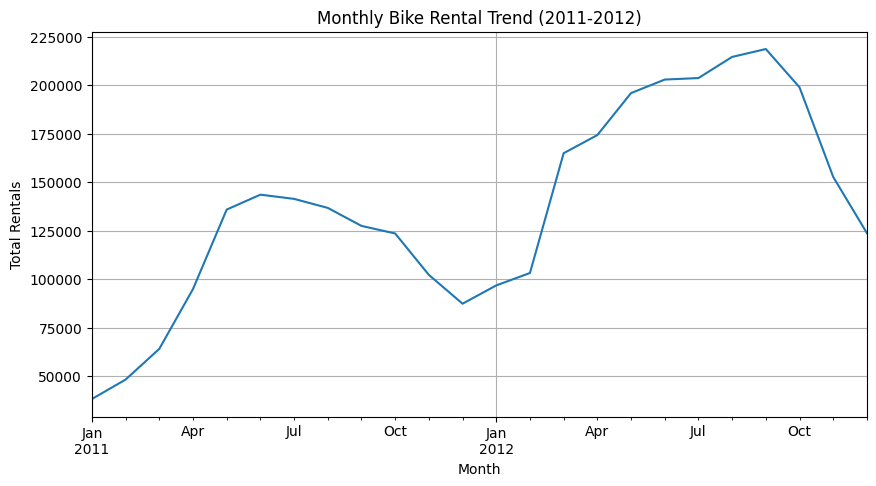

In [71]:

plt.figure(figsize=(10,5))
monthly_trend.plot()

plt.title("Monthly Bike Rental Trend (2011-2012)")
plt.xlabel("Month")
plt.ylabel("Total Rentals")
plt.grid()

plt.show()

### Pertanyaan 2:

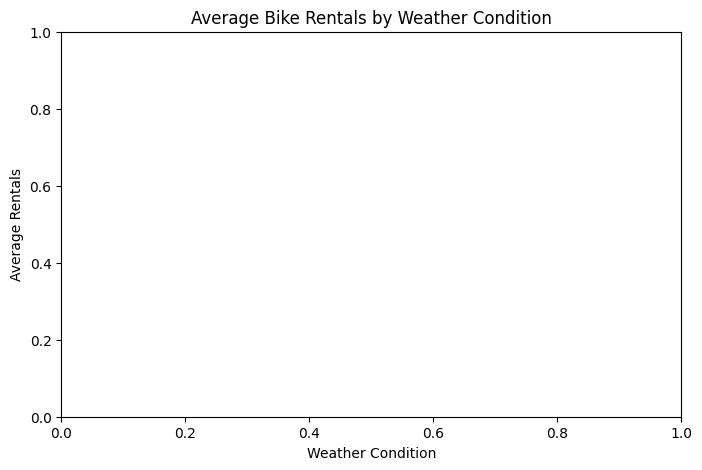

In [72]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=weather_trend.index,
    y=weather_trend.values
)

plt.title("Average Bike Rentals by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Rentals")

plt.show()

**Insight:** (Opsional)
- Terjadi peningkatan jumlah penyewaan sepeda pada periode pertengahan tahun
Puncak penyewaan umumnya terjadi pada musim panas
Terjadi penurunan penyewaan pada akhir dan awal tahun, kemungkinan disebabkan oleh kondisi cuaca yang kurang mendukung
- Penyewaan sepeda paling tinggi terjadi pada kondisi cuaca cerah (Clear)
Terjadi penurunan jumlah penyewaan pada kondisi berkabut (Mist)
Penyewaan paling rendah terjadi pada kondisi cuaca buruk seperti hujan atau salju

## Analisis Lanjutan (Opsional)

In [73]:
df['demand_level'] = pd.cut(
    df['cnt'],
    bins=[0, 2000, 4000, 7000],
    labels=['Low', 'Medium', 'High']
)

df[['cnt', 'demand_level']].head()

,cnt,demand_level
0,985,Low
1,801,Low
2,1349,Low
3,1562,Low
4,1600,Low


In [74]:
demand_dist = df['demand_level'].value_counts()

demand_dist

,count
demand_level,
High,358
Medium,181
Low,98


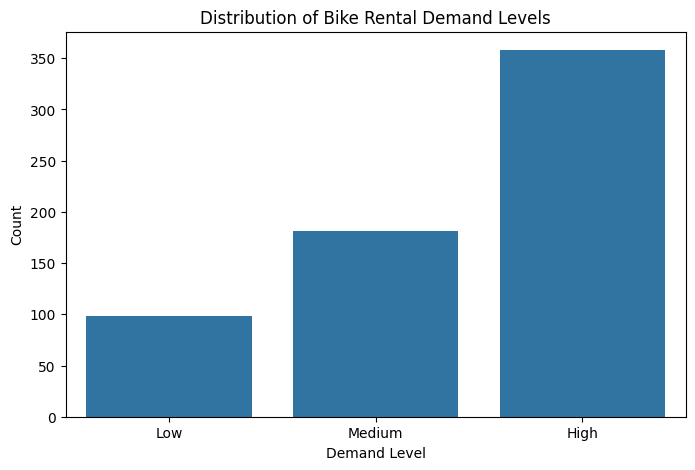

In [75]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='demand_level',
    data=df,
    order=['Low', 'Medium', 'High']
)

plt.title("Distribution of Bike Rental Demand Levels")
plt.xlabel("Demand Level")
plt.ylabel("Count")

plt.show()

## Conclusion & Recommendation

- **Conclusion Tren Penyewaan Sepeda:**
- Jumlah penyewaan sepeda menunjukkan pola musiman yang jelas
- Terjadi peningkatan signifikan pada pertengahan tahun (musim panas)
- Penurunan penyewaan terjadi pada awal dan akhir tahun, kemungkinan dipengaruhi oleh kondisi cuaca
- **Conclusion Pengaruh Kondisi Cuaca:** xxx
- Kondisi cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda
- Penyewaan tertinggi terjadi saat cuaca cerah (Clear)
- Penyewaan menurun pada kondisi berkabut (Mist)
- Penyewaan paling rendah terjadi saat cuaca buruk seperti hujan atau salj

**Rekomendasi Action Item:**
1. Optimalisasi Operasional Berdasarkan Musim.
- Menambah jumlah sepeda dan kapasitas layanan pada periode dengan permintaan tinggi (musim panas).
- Mengurangi operasional atau melakukan efisiensi pada periode permintaan rendah.
2. Strategi Berbasis Cuaca
- Menyesuaikan jumlah sepeda berdasarkan prediksi cuaca.
- Menyediakan promosi atau insentif pada kondisi cuaca buruk untuk menjaga tingkat penyewaan.
3. Manajemen Permintaan
- Mengantisipasi lonjakan permintaan pada kategori High dengan memastikan ketersediaan sepeda.
- Mengembangkan strategi pemasaran untuk meningkatkan permintaan pada kategori Low.
4. Pengambilan Keputusan Berbasis Data.
- Menggunakan hasil analisis ini sebagai dasar dalam perencanaan operasional dan strategi bisnis ke depan.

In [76]:
df.to_csv("main_data.csv", index=False)